In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib as plt
import seaborn as sns
%matplotlib inline

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session



In [2]:

titanic = pd.read_csv('../input/titanic/train.csv')
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#### DATA CLEANING

In [5]:
titanic.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
titanic.drop(["Cabin"],inplace=True,axis=1)
titanic.drop(["Ticket"],inplace=True,axis=1)
titanic.drop(["PassengerId"],inplace=True,axis=1)
titanic.drop(["Name"],inplace=True,axis=1)

titanic.sample(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
344,0,2,male,36.0,0,0,13.0000,S
361,0,2,male,29.0,1,0,27.7208,C
340,1,2,male,2.0,1,1,26.0000,S


In [7]:
titanic["Age"].fillna(titanic["Age"].median(),inplace=True)
titanic["Age"].isna().sum()

0

In [8]:
titanic.isna().sum()
titanic["Embarked"].fillna(titanic["Embarked"].mode(),inplace=True)
titanic["Embarked"].isna().sum()

2

Data is looking fine now

# VISUALIZING NOW

<AxesSubplot:>

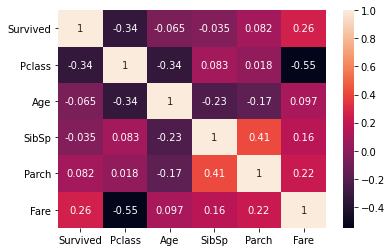

In [9]:
sns.heatmap(titanic.corr(),annot=True)

<AxesSubplot:xlabel='Survived', ylabel='count'>

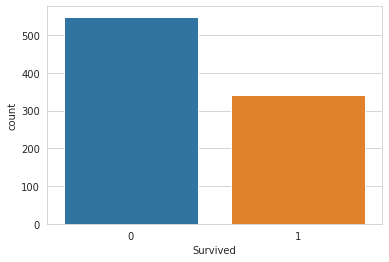

In [10]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',data=titanic)

In [11]:
a =  len(titanic[titanic["Survived"]==1])
b =  len(titanic["Survived"])

sur = (a / b) * 100 
print("only ",sur,"% of people survived")

only  38.38383838383838 % of people survived


/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


S    644
C    168
Q     77
Name: Embarked, dtype: int64

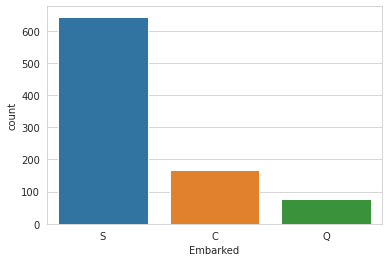

In [12]:

sns.countplot(titanic['Embarked'])
titanic['Embarked'].value_counts()

<AxesSubplot:xlabel='Sex', ylabel='count'>

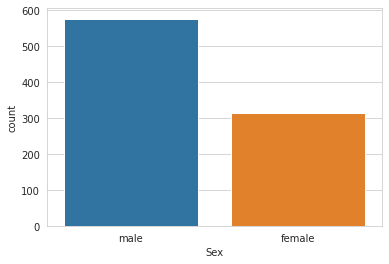

In [13]:
sns.set_style("whitegrid")
sns.countplot(x='Sex',data=titanic)

<AxesSubplot:xlabel='Survived', ylabel='count'>

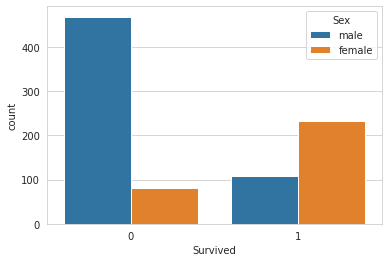

In [14]:
sns.set_style("whitegrid")
sns.countplot(x='Survived',hue='Sex',data=titanic)

<AxesSubplot:xlabel='Pclass', ylabel='Survived'>

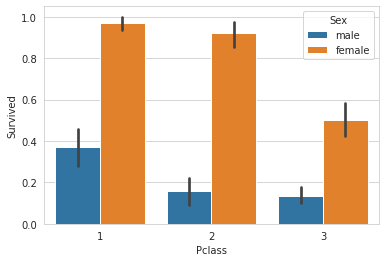

In [15]:
sns.set_style("whitegrid")
sns.barplot(y="Survived",x="Pclass",hue="Sex",data=titanic)

# CONCULUSION
1. > More female passengers survived than male passengers. 71% of the females survived compared to that of males (only 29% survived).

2. > Survivors tend to be older that those who did not.

3. > On average survivors paid higher fare than non-survivors. On average survivors paid 59units whereas non-surviours paid 32.6units******

/opt/conda/lib/python3.7/site-packages/seaborn/categorical.py:3714: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)
/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


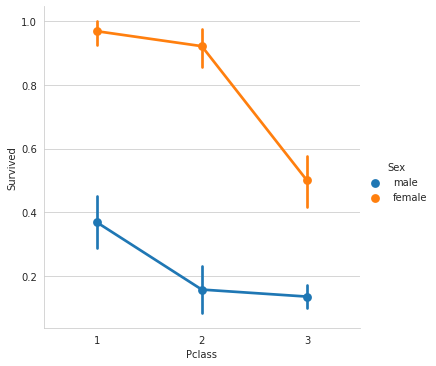

In [16]:
sns.factorplot('Pclass','Survived',hue='Sex',data=titanic)


# BUILING A PREDICTIVE MODEL

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X = titanic[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked']]
X = pd.get_dummies(X)
X.drop(["Sex_female"],inplace=True,axis=1)
X.drop(["Embarked_C"],inplace=True,axis=1)
X.sample(3)

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
870,3,26.0,0,0,7.8958,1,0,1
313,3,28.0,0,0,7.8958,1,0,1
0,3,22.0,1,0,7.2500,1,0,1


In [19]:
y = titanic['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, shuffle=True)

In [20]:
X

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,1,0,1
1,1,38.0,1,0,71.2833,0,0,0
2,3,26.0,0,0,7.9250,0,0,1
3,1,35.0,1,0,53.1000,0,0,1
4,3,35.0,0,0,8.0500,1,0,1
...,...,...,...,...,...,...,...,...
886,2,27.0,0,0,13.0000,1,0,1
887,1,19.0,0,0,30.0000,0,0,1
888,3,28.0,1,2,23.4500,0,0,1
889,1,26.0,0,0,30.0000,1,0,0


In [21]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)




# LOGISTIC REGRESSION

In [22]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

lr.fit(X_train,y_train)
prediction=lr.predict(X_test)

# RANDOM FOREST MODEL

In [23]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()

rfc=RandomForestClassifier(n_estimators=50)
rfc.fit(X_train,y_train)
prediction_rfc  =  rfc.predict(X_test)

# K NEAREST NEIGHBOUR

In [24]:
from sklearn.neighbors import KNeighborsClassifier #KNN

knn=KNeighborsClassifier() 
knn.fit(X_train,y_train)
prediction_knn=knn.predict(X_test)

# MODEL EVALUATION

In [25]:
from sklearn import metrics

print('SCORE FOR LOGISTIC REGRESION MODEL :  ',metrics.accuracy_score(prediction,y_test))

print("__________________________________________________")
print('SCORE FOR RANDOM FOREST MODEL :       ',metrics.accuracy_score(prediction_rfc,y_test))


print("__________________________________________________")
print('SCORE FOR KNN MODEL :                 ',metrics.accuracy_score(prediction_knn,y_test))

SCORE FOR LOGISTIC REGRESION MODEL :   0.8116591928251121
__________________________________________________
SCORE FOR RANDOM FOREST MODEL :        0.7937219730941704
__________________________________________________
SCORE FOR KNN MODEL :                  0.757847533632287


# AS WE CAN SEE ALL THE MODELS ACCUARY SCORE IS MORE THAN 75 
# WHRE RANDOM FOREST HAS HIGHEST ACCUARCY SCORE OF 83.9
so here random forest would be the suitable 